# Prédiction - Delphin-Eye

Charge le meilleur modèle entraîné et lance la détection sur de nouvelles images.

In [1]:
from pathlib import Path
from ultralytics import YOLO
import shutil

PROJECT_ROOT = Path.cwd().parent

BEST_WEIGHTS = PROJECT_ROOT / "output" / "models" / "default" / "weights" / "best.pt"
IMAGES_DIR = PROJECT_ROOT / "data" / "predict"
OUTPUT_DIR = PROJECT_ROOT / "output"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
MAX_IMAGES = 26  # None = toutes les images

assert BEST_WEIGHTS.exists(), f"Modèle introuvable : {BEST_WEIGHTS}"
assert IMAGES_DIR.exists(), f"Crée le dossier et ajoutes-y des images : {IMAGES_DIR}"
print(f"Modèle : {BEST_WEIGHTS}")

Modèle : c:\src\projects\school\etude_recherche\delphin-eye\output\models\default\weights\best.pt


In [2]:
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
MAX_SIZE = 1280  # px (côté le plus long)
TEMP_DIR = OUTPUT_DIR / "predict_tmp"

def preprocess_images(src_dir, dst_dir, max_size):
    dst_dir.mkdir(parents=True, exist_ok=True)
    sources = [p for p in sorted(src_dir.iterdir()) if p.suffix in IMAGE_EXTENSIONS]
    if MAX_IMAGES:
        sources = sources[:MAX_IMAGES]
    for src in sources:
        img = Image.open(src)
        img.thumbnail((max_size, max_size), Image.LANCZOS)
        dst = dst_dir / (src.stem + ".jpg")
        img.save(dst, "JPEG", quality=85)
    print(f"{len(sources)} images redimensionnées dans {dst_dir}")
    return dst_dir

preprocess_images(IMAGES_DIR, TEMP_DIR, MAX_SIZE)

26 images redimensionnées dans c:\src\projects\school\etude_recherche\delphin-eye\output\predict_tmp


WindowsPath('c:/src/projects/school/etude_recherche/delphin-eye/output/predict_tmp')

In [3]:
model = YOLO(str(BEST_WEIGHTS))

sources = sorted(TEMP_DIR.glob("*.jpg"))
print(f"{len(sources)} images à traiter")

if PREDICTIONS_DIR.exists():
    shutil.rmtree(PREDICTIONS_DIR)

results = model.predict(
    source=sources,
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    stream=True,
    project=str(OUTPUT_DIR),
    name="predictions",
)

n = 0
for r in results:
    n += 1

print(f"\n{n} images traitées.")
print(f"Résultats sauvegardés dans : {PREDICTIONS_DIR}")

26 images à traiter

0: 448x640 (no detections), 54.8ms
1: 448x640 (no detections), 54.8ms
2: 448x640 1 dorsal_fin, 54.8ms
3: 448x640 1 dorsal_fin, 54.8ms
4: 448x640 (no detections), 54.8ms
5: 448x640 1 dorsal_fin, 54.8ms
6: 448x640 1 dorsal_fin, 54.8ms
7: 448x640 (no detections), 54.8ms
8: 448x640 (no detections), 54.8ms
9: 448x640 (no detections), 54.8ms
10: 448x640 (no detections), 54.8ms
11: 448x640 1 dorsal_fin, 54.8ms
12: 448x640 (no detections), 54.8ms
13: 448x640 (no detections), 54.8ms
14: 448x640 1 dorsal_fin, 54.8ms
15: 448x640 (no detections), 54.8ms
16: 448x640 1 dorsal_fin, 54.8ms
17: 448x640 2 dorsal_fins, 54.8ms
18: 448x640 2 dorsal_fins, 54.8ms
19: 448x640 1 dorsal_fin, 54.8ms
20: 448x640 2 dorsal_fins, 54.8ms
21: 448x640 (no detections), 54.8ms
22: 448x640 (no detections), 54.8ms
23: 448x640 (no detections), 54.8ms
24: 448x640 1 dorsal_fin, 54.8ms
25: 448x640 2 dorsal_fins, 54.8ms
Speed: 3.2ms preprocess, 54.8ms inference, 0.2ms postprocess per image at shape (1, 3, 4

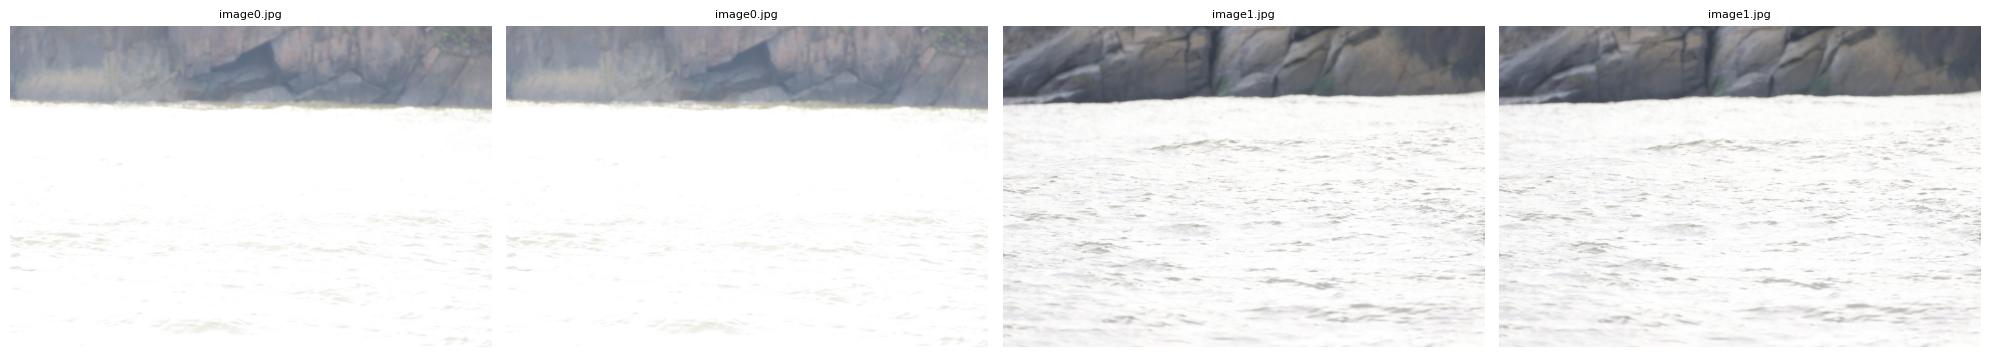

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pred_images = [p for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.png") for p in PREDICTIONS_DIR.glob(ext)]
pred_images = sorted(pred_images)[:4]

if not pred_images:
    print(f"Aucune image trouvée dans {PREDICTIONS_DIR}")
else:
    fig, axes = plt.subplots(1, len(pred_images), figsize=(5 * len(pred_images), 5))
    if len(pred_images) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, pred_images):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(img_path.name, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
if TEMP_DIR.exists():
    shutil.rmtree(TEMP_DIR)
    print(f"Dossier temporaire supprimé : {TEMP_DIR}")

Dossier temporaire supprimé : c:\src\projects\school\etude_recherche\delphin-eye\output\predict_tmp
